In [2]:
import os
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input

print('TensorFlow:', tf.__version__)

SEED = 42
keras.utils.set_random_seed(SEED)
autotune = tf.data.AUTOTUNE

TensorFlow: 2.20.0


In [3]:
import ctypes

train_dir = "C:/Users/nguye/OneDrive/Máy tính/University courses/Sem1_2026/COS30082/Week5/train"


def windows_short_path(p: Path) -> str:
    s = str(p)
    if os.name != 'nt':
        return s
    GetShortPathNameW = ctypes.windll.kernel32.GetShortPathNameW
    GetShortPathNameW.argtypes = [ctypes.c_wchar_p, ctypes.c_wchar_p, ctypes.c_uint]
    GetShortPathNameW.restype = ctypes.c_uint
    buf = ctypes.create_unicode_buffer(4096)
    n = GetShortPathNameW(s, buf, 4096)
    return buf.value if n != 0 else s

train_dir_arg = windows_short_path(train_dir)

print('train_dir:', train_dir)
print('train_dir_arg:', train_dir_arg)

train_dir: C:/Users/nguye/OneDrive/Máy tính/University courses/Sem1_2026/COS30082/Week5/train
train_dir_arg: C:/Users/nguye/OneDrive/MYTNH~1/UNIVER~1/SEM1_2~3/COS30082/Week5/train


In [4]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = keras.utils.image_dataset_from_directory(
    train_dir_arg,
    labels='inferred',
    label_mode='int',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=0.2,
    subset='training',
)

val_ds = keras.utils.image_dataset_from_directory(
    train_dir_arg,
    labels='inferred',
    label_mode='int',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=0.2,
    subset='validation',
)

class_names = train_ds.class_names
num_classes = len(class_names)
print('Classes (n=%d):' % num_classes, class_names)


def preprocess(x, y):
    return preprocess_input(tf.cast(x, tf.float32)), y


train_ds = train_ds.map(preprocess, num_parallel_calls=autotune).prefetch(autotune)
val_ds = val_ds.map(preprocess, num_parallel_calls=autotune).prefetch(autotune)

Found 10008 files belonging to 10 classes.
Using 8007 files for training.
Found 10008 files belonging to 10 classes.
Using 2001 files for validation.
Classes (n=10): ['Amphibia', 'Animalia', 'Arachnida', 'Aves', 'Fungi', 'Insecta', 'Mammalia', 'Mollusca', 'Plantae', 'Reptilia']


Found 10008 files belonging to 10 classes.
Using 8007 files for training.


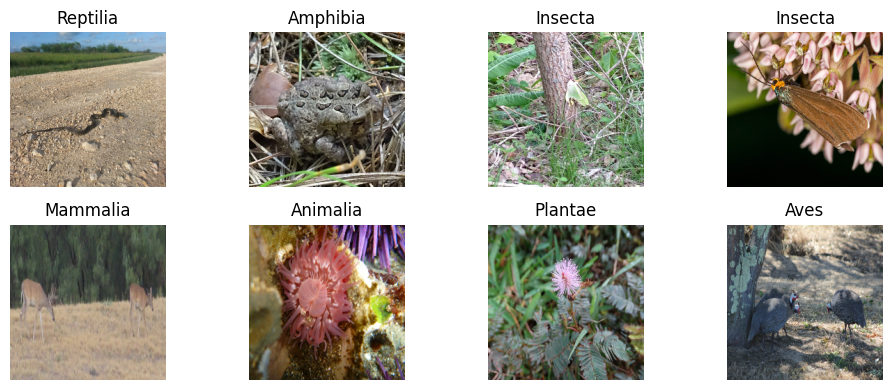

In [5]:
# Display unprocessed images
raw_train = keras.utils.image_dataset_from_directory(
    train_dir_arg,
    labels='inferred',
    label_mode='int',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=0.2,
    subset='training',
)
plt.figure(figsize=(10, 4))
for images, labels in raw_train.take(1):
    for i in range(min(8, images.shape[0])):
        ax = plt.subplot(2, 4, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[int(labels[i])])
        plt.axis('off')
plt.tight_layout()
plt.show()

In [6]:
def build_model(freeze_base: bool):
    base = MobileNetV2(
        input_shape=(*IMG_SIZE, 3),
        include_top=False,
        weights='imagenet',
    )
    base.trainable = not freeze_base
    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs, name='transfer_mobilenetv2')


model_fe = build_model(freeze_base=True)
model_fe.summary()

Model: "transfer_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
model_fe.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
)

EPOCHS_FE = 15  

t0 = time.perf_counter()
hist_fe = model_fe.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FE, verbose=1)
time_fe = time.perf_counter() - t0

val_loss_fe, val_acc_fe = model_fe.evaluate(val_ds, verbose=0)
print(f'\n[Feature extraction] val_accuracy={val_acc_fe:.4f}  training_time={time_fe:.2f}s')

Epoch 1/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 100s 388ms/step - accuracy: 0.6432 - loss: 1.1205 - val_accuracy: 0.7296 - val_loss: 0.8351
Epoch 2/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 97s 385ms/step - accuracy: 0.7528 - loss: 0.7775 - val_accuracy: 0.7421 - val_loss: 0.7876
Epoch 3/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 96s 382ms/step - accuracy: 0.7695 - loss: 0.6964 - val_accuracy: 0.7481 - val_loss: 0.7672
Epoch 4/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 99s 395ms/step - accuracy: 0.7868 - loss: 0.6537 - val_accuracy: 0.7511 - val_loss: 0.7628
Epoch 5/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 108s 429ms/step - accuracy: 0.7968 - loss: 0.6108 - val_accuracy: 0.7516 - val_loss: 0.7734
Epoch 6/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 110s 436ms/step - accuracy: 0.8033 - loss: 0.5894 - val_accuracy: 0.7531 - val_loss: 0.7742
Epoch 7/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 100s 399ms/step - accuracy: 0.8157 - loss: 0.5666 - val_accuracy: 0.7546 - val_loss: 0.7827
Epoch 8/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 102s 407ms/step - accuracy: 0.8195 - lo

In [8]:
# Find the MobileNetV2 sub-model
base = None
for lyr in model_fe.layers:
    if isinstance(lyr, keras.Model) and len(getattr(lyr, 'layers', [])) > 0:
        base = lyr
        break
if base is None:
    raise RuntimeError('Could not find base MobileNet layer in model_fe')
base.trainable = True

# Freeze bottom layers and train top ~40 layers (tune as needed)
fine_tune_at = len(base.layers) - 40
for layer in base.layers[:fine_tune_at]:
    layer.trainable = False

trainable_count = sum(1 for l in base.layers if l.trainable)
print('Unfrozen layers in base:', trainable_count)

model_fe.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
)

EPOCHS_FT = 15

t1 = time.perf_counter()
hist_ft = model_fe.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FT, verbose=1)
time_ft = time.perf_counter() - t1

val_loss_ft, val_acc_ft = model_fe.evaluate(val_ds, verbose=0)
print(f'\n[Fine-tuning] val_accuracy={val_acc_ft:.4f}  training_time={time_ft:.2f}s')

Unfrozen layers in base: 40
Epoch 1/15


251/251 ━━━━━━━━━━━━━━━━━━━━ 133s 506ms/step - accuracy: 0.6960 - loss: 0.9466 - val_accuracy: 0.7496 - val_loss: 0.8675
Epoch 2/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 128s 508ms/step - accuracy: 0.7714 - loss: 0.6675 - val_accuracy: 0.7511 - val_loss: 0.8483
Epoch 3/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 125s 496ms/step - accuracy: 0.7966 - loss: 0.6006 - val_accuracy: 0.7501 - val_loss: 0.8223
Epoch 4/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 125s 496ms/step - accuracy: 0.8137 - loss: 0.5486 - val_accuracy: 0.7501 - val_loss: 0.8092
Epoch 5/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 125s 496ms/step - accuracy: 0.8354 - loss: 0.4848 - val_accuracy: 0.7496 - val_loss: 0.7906
Epoch 6/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 134s 531ms/step - accuracy: 0.8528 - loss: 0.4358 - val_accuracy: 0.7521 - val_loss: 0.7877
Epoch 7/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 131s 522ms/step - accuracy: 0.8651 - loss: 0.3978 - val_accuracy: 0.7526 - val_loss: 0.7849
Epoch 8/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 121s 481ms/step - accuracy: 0.8761 - loss: 0.36

In [9]:
print('\nSummary:')
print(f"+ Feature extraction: last epoch val acc: {hist_fe.history['val_accuracy'][-1]:.4f}, fit time: {time_fe:.2f}s")
print(f"+ Fine-tuning: last epoch val acc: {hist_ft.history['val_accuracy'][-1]:.4f}, fit time: {time_ft:.2f}s")
print(f"+ Final val_accuracy (after FT): {val_acc_ft:.4f}")


Summary:
+ Feature extraction: last epoch val acc: 0.7476, fit time: 1525.37s
+ Fine-tuning: last epoch val acc: 0.7606, fit time: 1860.15s
+ Final val_accuracy (after FT): 0.7606


In [10]:
def model_summary_text(m: keras.Model) -> str:
    lines = []
    m.summary(print_fn=lambda s: lines.append(s))
    return '\n'.join(lines)

report = []
report.append('* Lab 5 - Transfer Learning Report\n\n')
report.append('** Pre-trained model\n')
report.append('- **MobileNetV2** with ImageNet weights (`include_top=False`)\n')
report.append('- Head: GlobalAveragePooling2D → Dropout(0.2) → Dense(num_classes, softmax)\n\n')
report.append('** Architecture\n')
report.append('Full Keras `model.summary()` for `transfer_mobilenetv2` (state after fine-tuning).\n')
report.append(model_summary_text(model_fe))
report.append('** Feature extraction vs fine-tuning\n')
report.append('Stage | Val accuracy (last epoch) | Training time (s)\n')
report.append(f"Feature extraction | {hist_fe.history['val_accuracy'][-1]:.4f} | {time_fe:.2f}\n")
report.append(f"Fine-tuning | {hist_ft.history['val_accuracy'][-1]:.4f} | {time_ft:.2f}")
report.append(f"\nFinal validation accuracy after fine-tuning: {val_acc_ft:.4f}\n")

p = Path.cwd() / 'lab05_report.md'
p.write_text(''.join(report), encoding='utf-8')
print('Saved report:', p)

Saved report: c:\Users\nguye\OneDrive\Máy tính\University courses\Sem1_2026\COS30082\Week5\lab05_report.md
